<a href="https://www.kaggle.com/code/omborse771924/new-york-sold-real-estate-intelligence-2026-eda?scriptVersionId=324548036" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv


## LoadData Set

In [2]:
df = pd.read_csv('/kaggle/input/datasets/kanchana1990/new-york-sold-real-estate-intelligence-2026/ny_real_estate_sold_properties_2026.csv')

In [3]:
df.head()

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
0,multi_family,NaN,SOLD before print,157500.0,157500,2132.0,NaN,4.0,2.0,2.0,...,Troy,1.0000,73.87,73.87,At Asking,2.0,0,1,Large (2000-3500),1
1,single_family,NaN,Sold Before Print,205000.0,205000,1946.0,NaN,4.0,4.0,3.0,...,Rotterdam,1.0000,105.34,105.34,At Asking,3.0,1,1,Mid (1250-2000),1
2,single_family,NaN,An opportunity to own a piece of property with...,329000.0,305000,2637.0,2.0,4.0,3.0,3.0,...,Saranac Lake,0.9271,115.66,124.76,Below Asking,3.0,1,1,Large (2000-3500),1
3,single_family,NaN,Beautiful setting on 8 acres in Vermontville. ...,285000.0,290000,1800.0,2.0,4.0,2.0,1.0,...,Vermontville,1.0175,161.11,158.33,Above Asking,1.0,0,1,Mid (1250-2000),1
4,single_family,NaN,"**Auction Property, the online sales event for...",1.0,74552,1404.0,NaN,3.0,1.0,1.0,...,Pottersville,74552.0000,53.10,0.00,Above Asking,1.0,0,1,Mid (1250-2000),1


In [4]:
df.tail()

,type,sub_type,text,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,...,city,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,sold_vs_asking,total_baths,has_garage,has_list_price,size_tier,sqft_available
10249,coop,co_op,JUST LISTED - Turn-Key Renovated One-Bedroom o...,550000.0,525000,NaN,15.0,1.0,NaN,NaN,...,New York,0.9545,NaN,NaN,Below Asking,0.0,0,1,NaN,0
10250,coop,co_op,"Bright and cozy 1-bedroom, 1-bathroom unit in ...",229999.0,230000,710.0,NaN,1.0,1.0,1.0,...,Oakland Gardens,1.0000,323.94,323.94,At Asking,1.0,0,1,Micro (<750),1
10251,coop,co_op,"This move-in-ready, well-maintained 1-bedroom ...",244900.0,250000,820.0,1.0,1.0,1.0,1.0,...,Selden,1.0208,304.88,298.66,Above Asking,1.0,0,1,Small (750-1250),1
10252,other,NaN,NaN,NaN,900000,4240.0,2.0,7.0,2.0,2.0,...,Marlboro,NaN,212.26,NaN,No List Price,2.0,0,0,Luxury (3500+),1
10253,coop,co_op,Nestled within one of Chelsea's most distingui...,1675000.0,1675000,NaN,20.0,2.0,NaN,NaN,...,New York,1.0000,NaN,NaN,At Asking,0.0,0,1,NaN,0


In [5]:
df.describe()

,listPrice,lastSoldPrice,sqft,stories,beds,baths,baths_full,baths_full_calc,garage,zip_code,sold_list_ratio,price_per_sqft_sold,price_per_sqft_list,total_baths,has_garage,has_list_price,sqft_available
count,7.345000e+03,1.025400e+04,9988.000000,7083.000000,8582.000000,9996.000000,8605.000000,8613.000000,5020.000000,10254.000000,7345.000000,9989.000000,7092.000000,10254.000000,10254.000000,10254.000000,10254.000000
mean,6.161016e+05,7.654686e+05,1915.298358,3.477340,3.350734,1.955182,1.845322,1.875189,1.667331,12385.093427,116.779699,448.045950,376.993057,1.552077,0.489565,0.716306,0.974059
std,9.589015e+05,1.231452e+06,1538.521214,7.231371,1.308506,1.303166,0.953298,1.002020,0.965890,1422.761881,6392.334586,3528.170117,4135.535543,1.113902,0.499915,0.450812,0.158967
min,1.000000e+00,1.000000e+04,2.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,10001.000000,0.122500,1.600000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.299000e+05,2.580000e+05,1224.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,11354.000000,0.964900,167.840000,150.472500,1.000000,0.000000,0.000000,1.000000
50%,3.890000e+05,4.799000e+05,1624.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,12118.000000,1.000000,277.520000,230.190000,2.000000,0.000000,1.000000,1.000000
75%,7.100000e+05,8.500000e+05,2212.000000,2.000000,4.000000,3.000000,2.000000,2.000000,2.000000,13648.000000,1.063700,499.320000,416.105000,2.000000,1.000000,1.000000,1.000000
max,3.500000e+07,4.333300e+07,36795.000000,98.000000,16.000000,16.000000,24.000000,24.000000,40.000000,18848.000000,514800.000000,350000.000000,347500.000000,24.000000,1.000000,1.000000,1.000000


In [6]:
df.isnull().sum()

type                      0
sub_type               9112
text                   2968
listPrice              2909
lastSoldPrice             0
sqft                    266
stories                3171
beds                   1672
baths                   258
baths_full             1649
baths_full_calc        1641
garage                 5234
zip_code                  0
city                      0
sold_list_ratio        2909
price_per_sqft_sold     265
price_per_sqft_list    3162
sold_vs_asking            0
total_baths               0
has_garage                0
has_list_price            0
size_tier               265
sqft_available            0
dtype: int64

In [7]:
categorical_cols = [
    'sub_type',
    'text',
    'size_tier'
]


for col in categorical_cols:
    
    df[col] = df[col].fillna(
        "Unknown"
    )



# =====================================================
# NUMERICAL NULL HANDLING
# =====================================================

numerical_cols = [

    'listPrice',
    'sqft',
    'stories',
    'beds',
    'baths',
    'baths_full',
    'baths_full_calc',
    'garage',
    'sold_list_ratio',
    'price_per_sqft_sold',
    'price_per_sqft_list'

]


for col in numerical_cols:
    
    df[col] = df[col].fillna(
        df[col].median()
    )


In [8]:
df.isnull().sum()

type                   0
sub_type               0
text                   0
listPrice              0
lastSoldPrice          0
sqft                   0
stories                0
beds                   0
baths                  0
baths_full             0
baths_full_calc        0
garage                 0
zip_code               0
city                   0
sold_list_ratio        0
price_per_sqft_sold    0
price_per_sqft_list    0
sold_vs_asking         0
total_baths            0
has_garage             0
has_list_price         0
size_tier              0
sqft_available         0
dtype: int64

In [9]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10249    False
10250    False
10251    False
10252    False
10253    False
Length: 10254, dtype: bool

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.columns

Index(['type', 'sub_type', 'text', 'listPrice', 'lastSoldPrice', 'sqft',
       'stories', 'beds', 'baths', 'baths_full', 'baths_full_calc', 'garage',
       'zip_code', 'city', 'sold_list_ratio', 'price_per_sqft_sold',
       'price_per_sqft_list', 'sold_vs_asking', 'total_baths', 'has_garage',
       'has_list_price', 'size_tier', 'sqft_available'],
      dtype='object')

## EDA

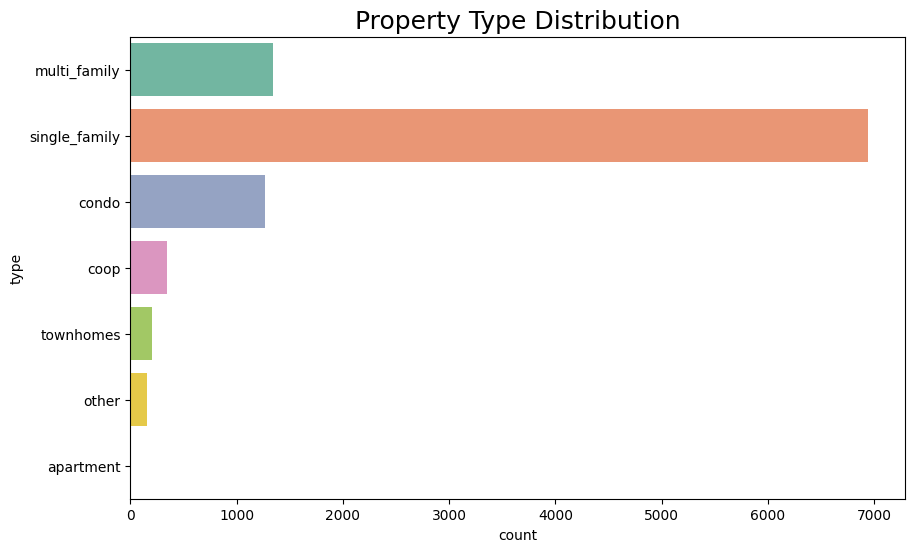

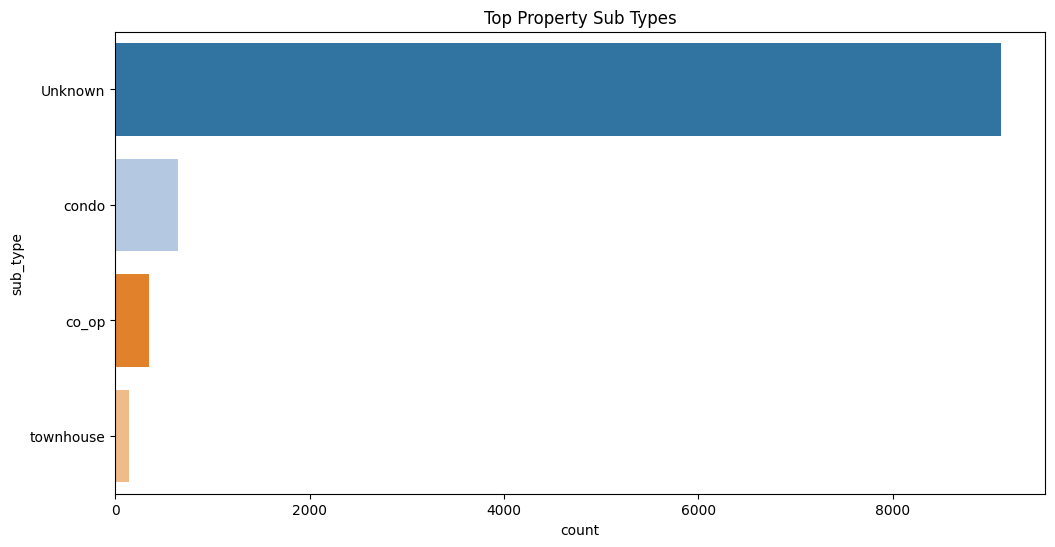

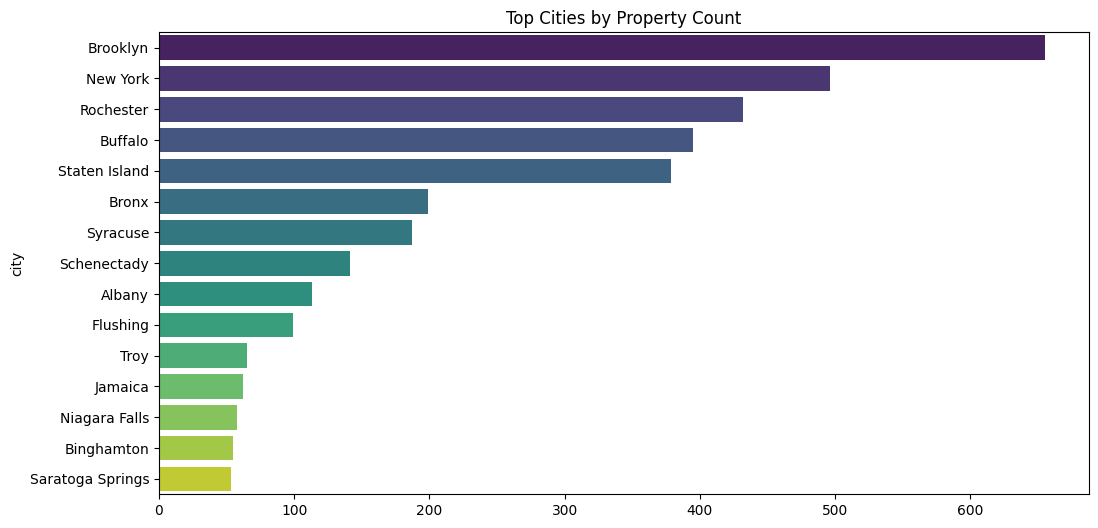

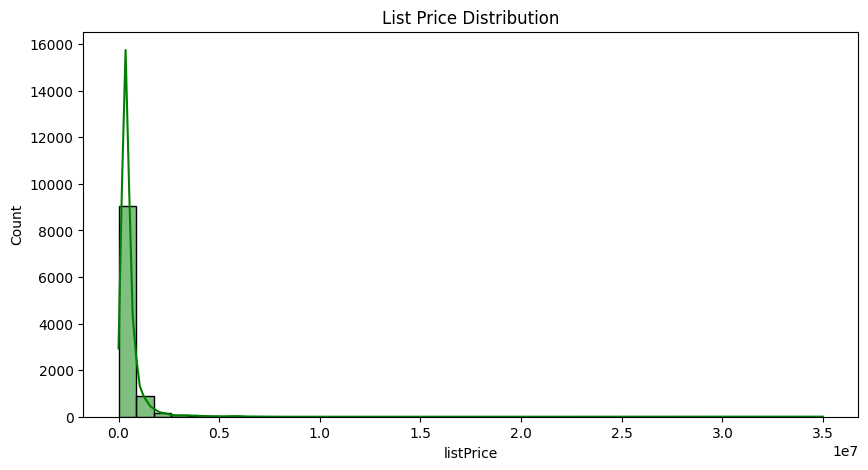

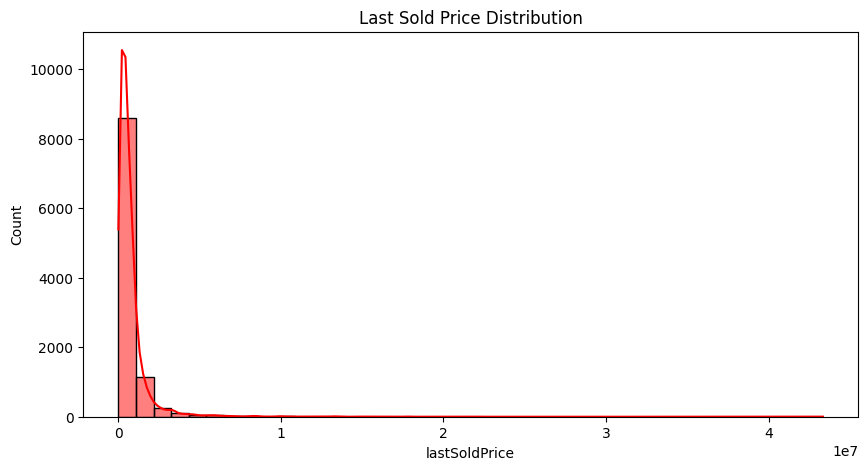

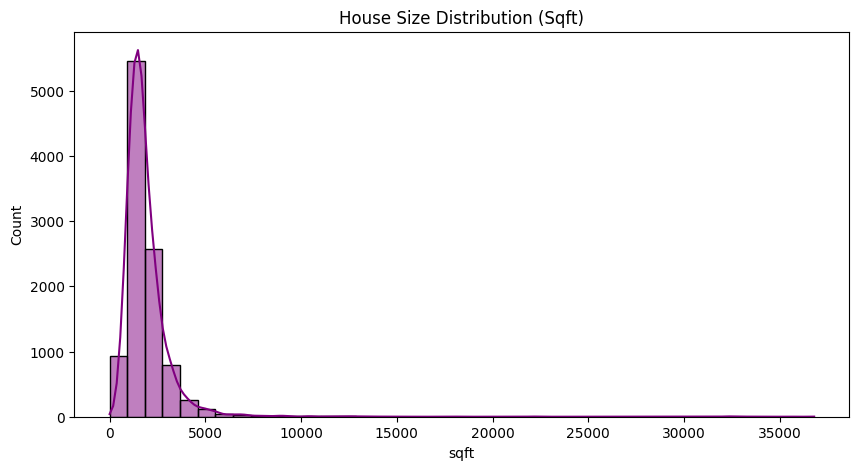

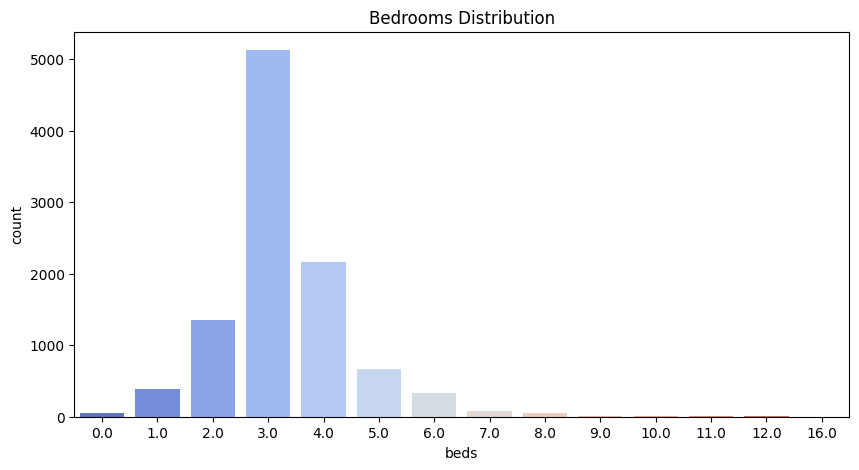

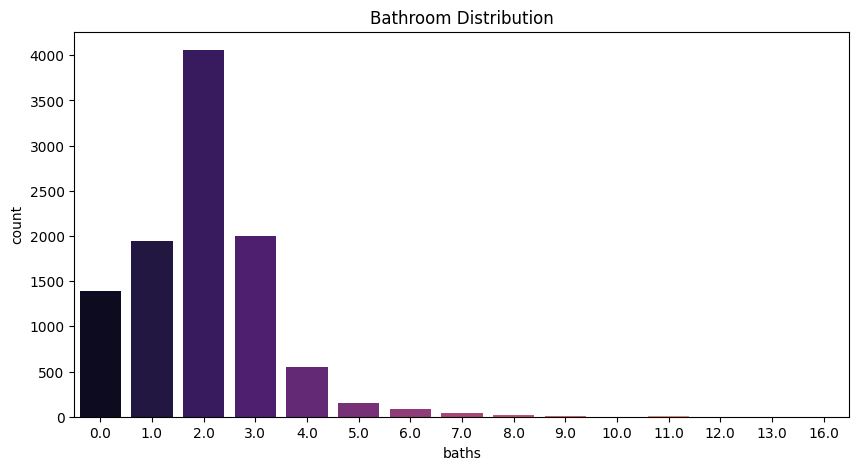

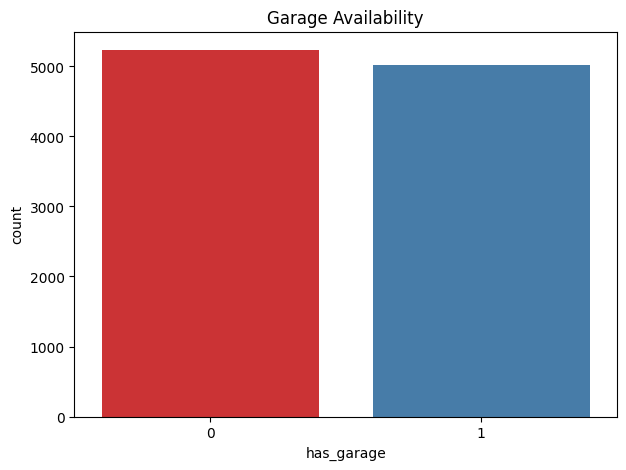

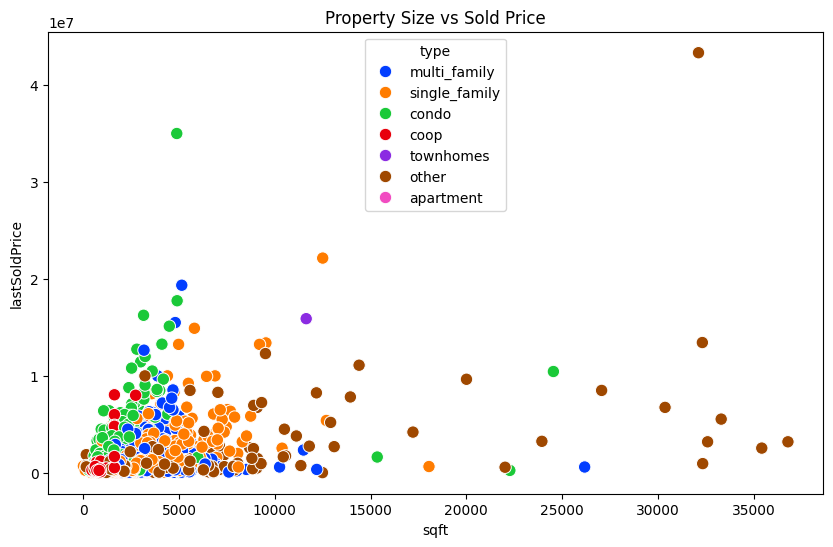

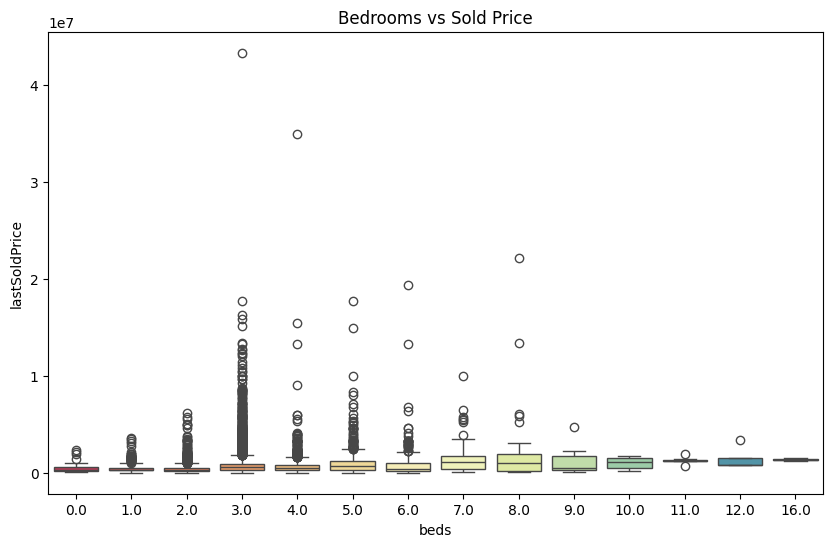

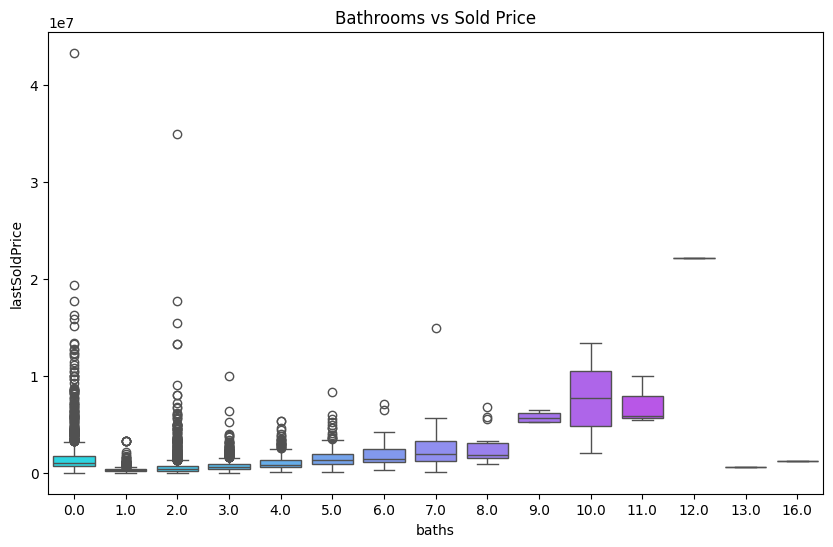

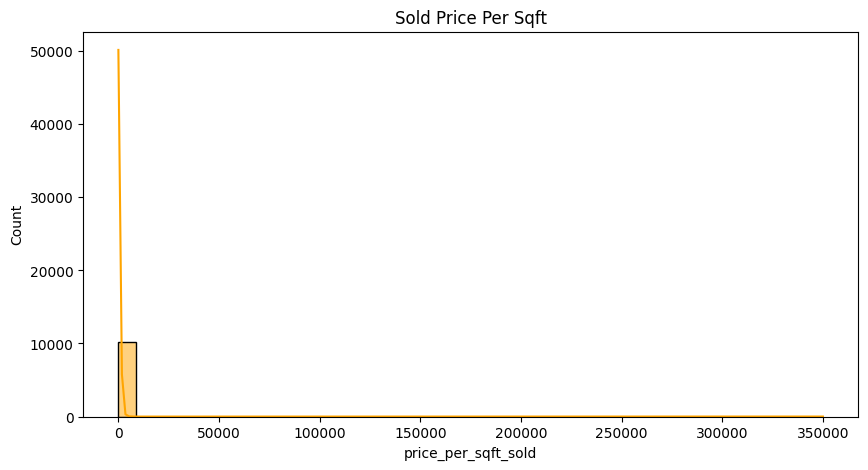

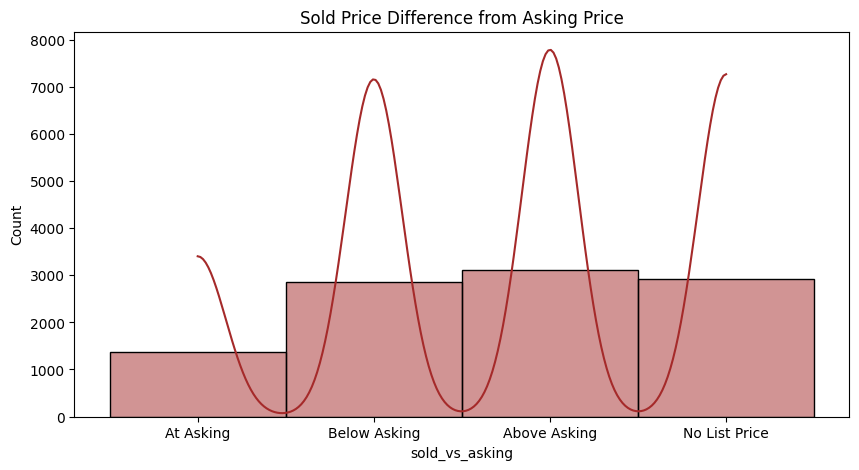

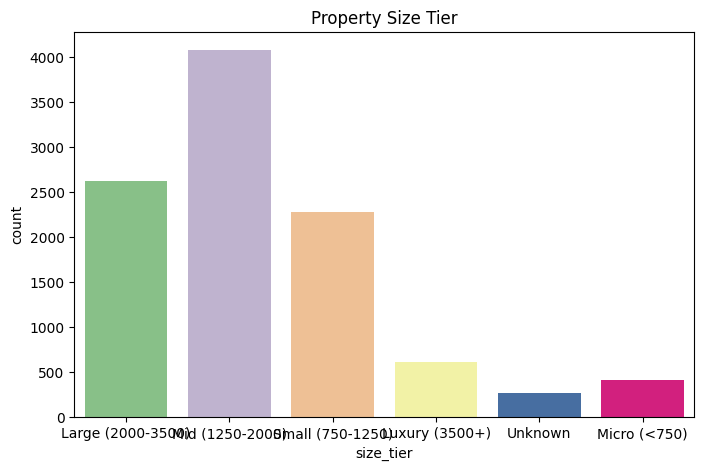

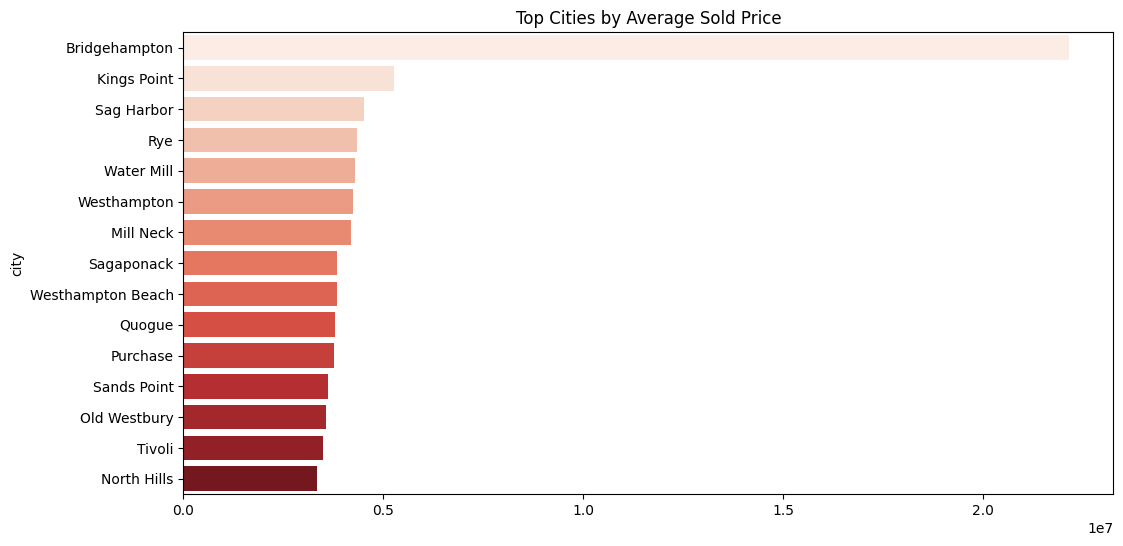

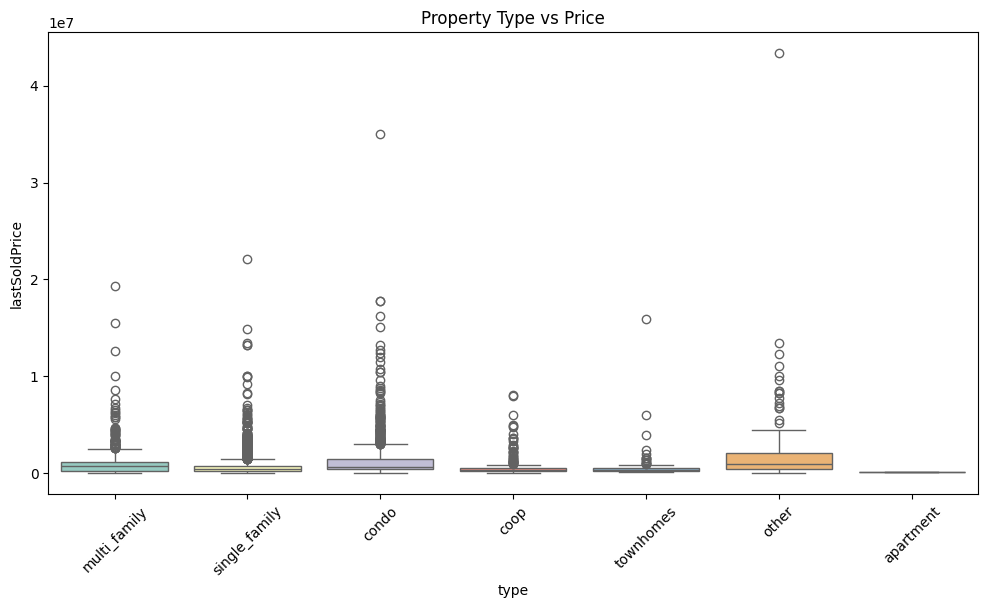

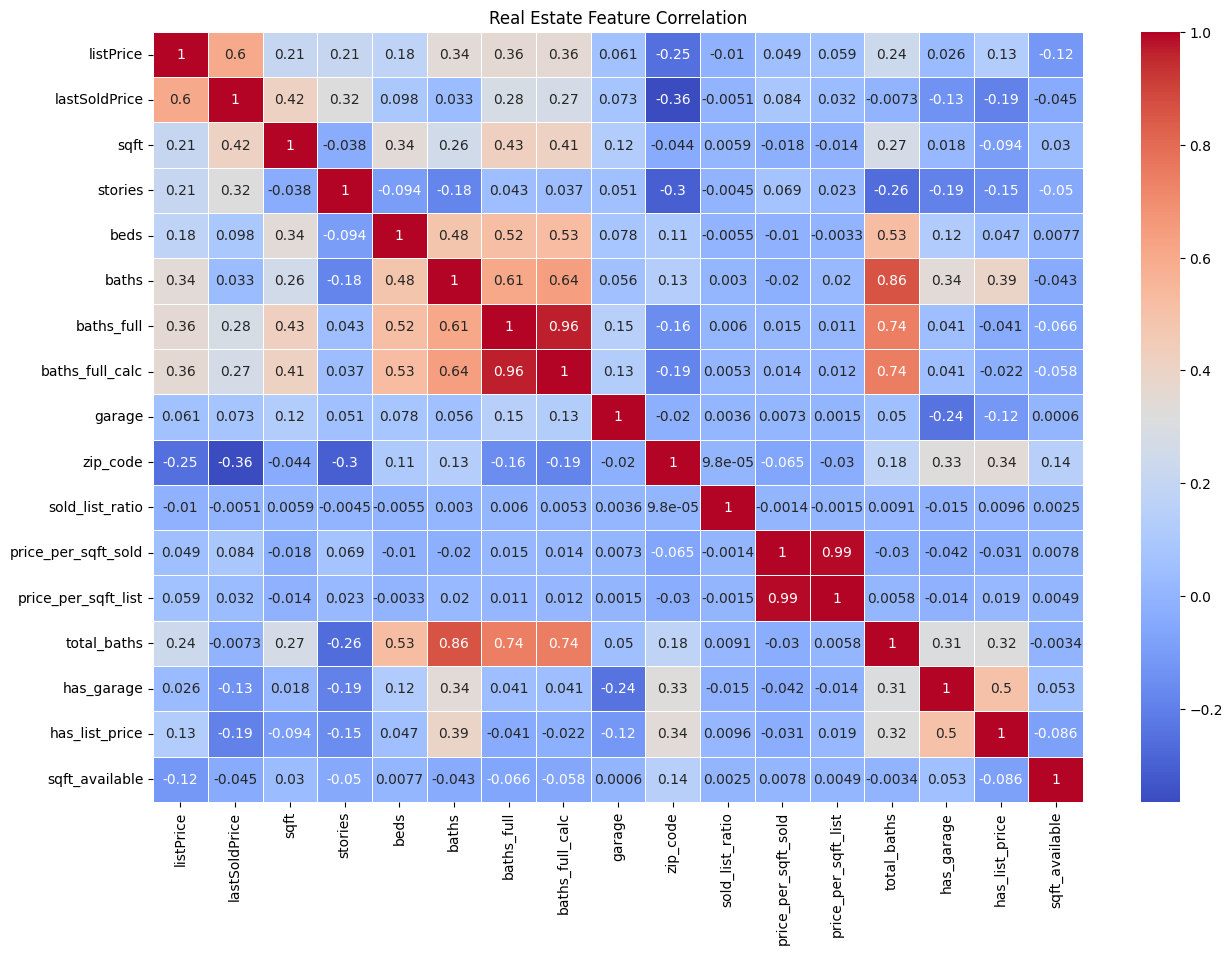

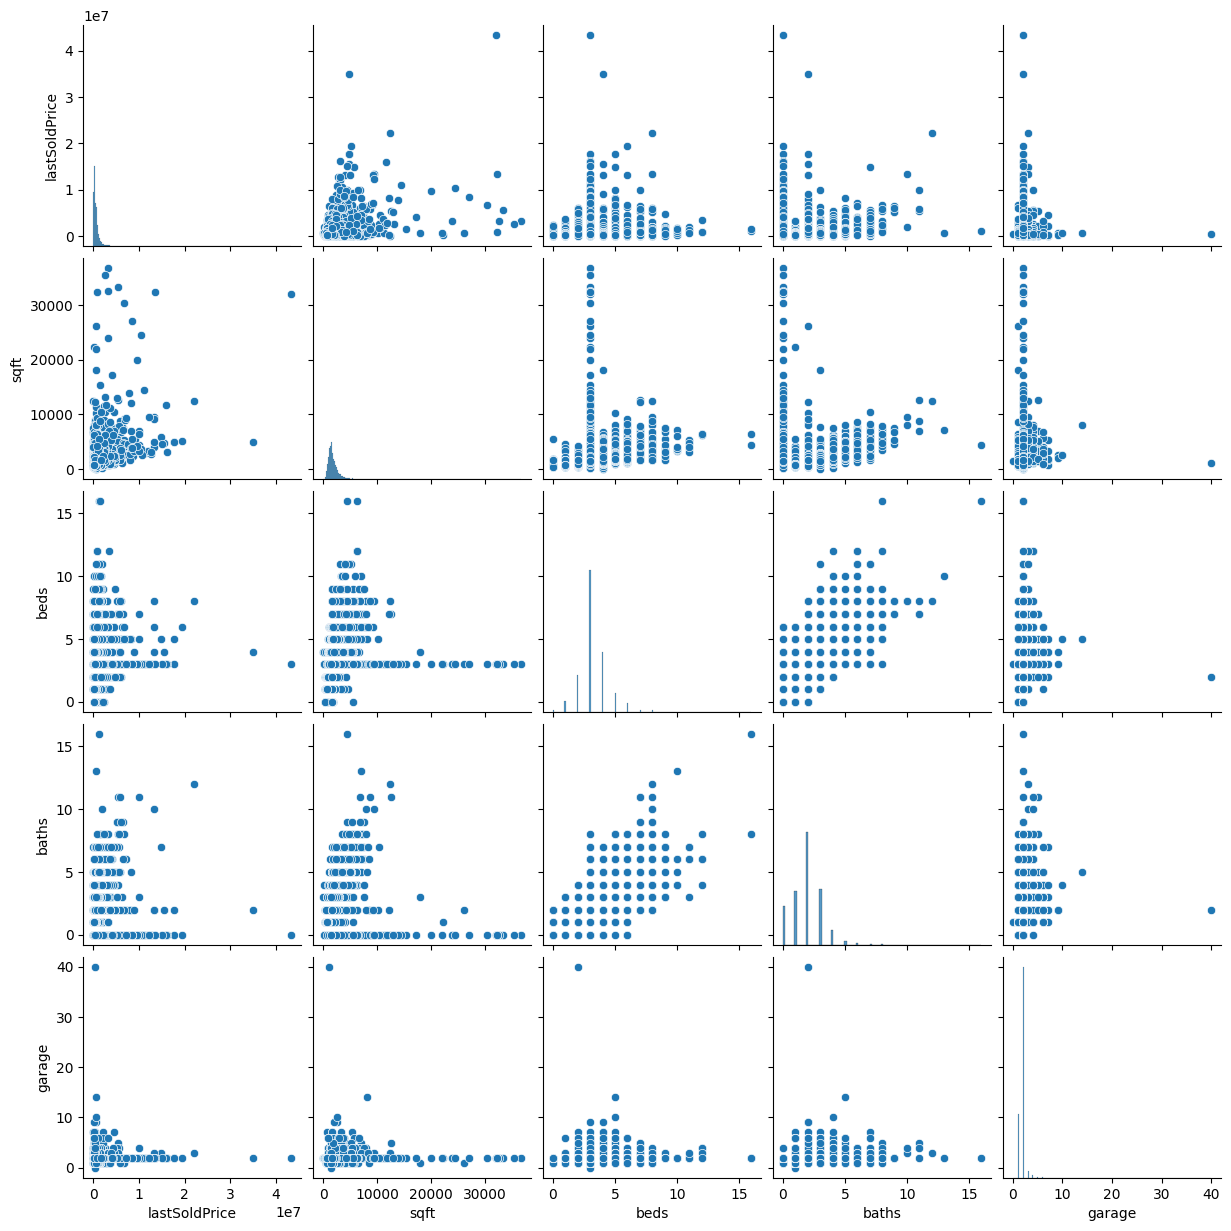

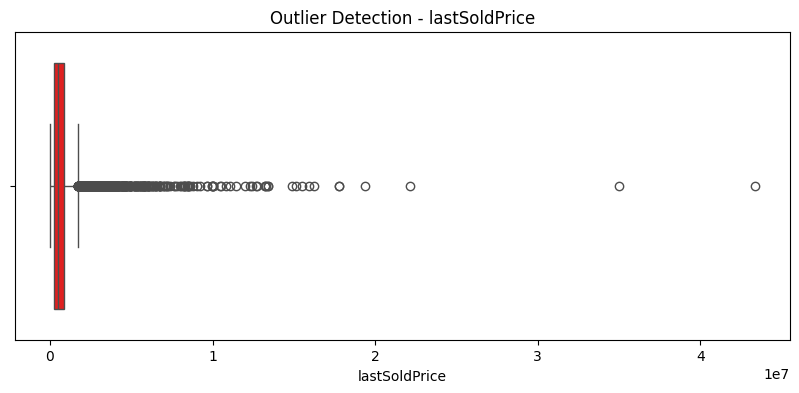

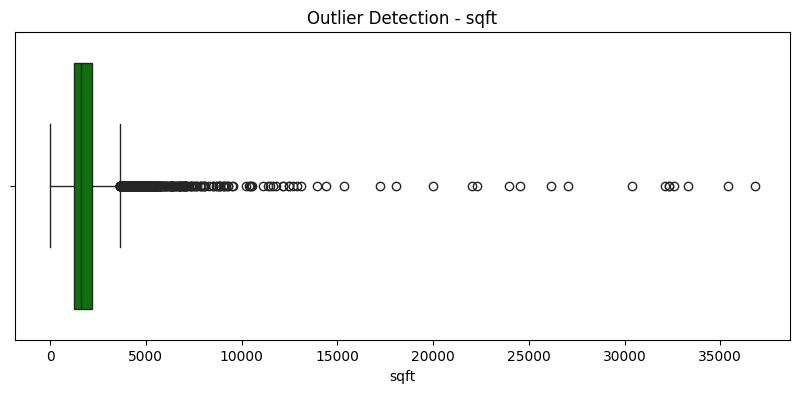

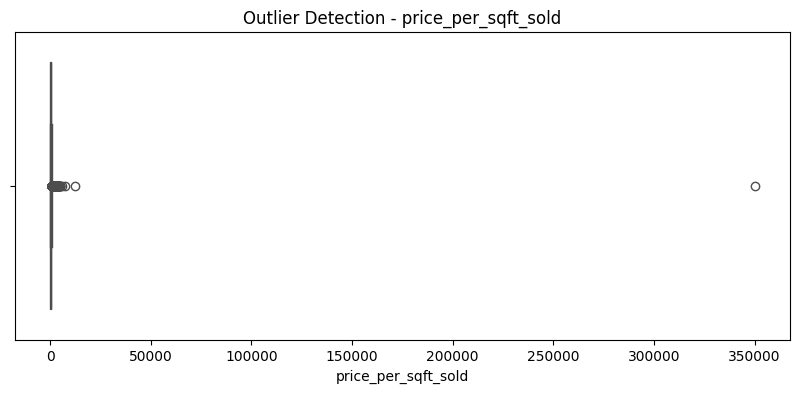

Real Estate Detailed Visualization Completed Successfully!


In [12]:
# ============================================================
# REAL ESTATE DATASET - DETAILED VISUALIZATION
# ============================================================







# ============================================================
# 1. PROPERTY TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.countplot(
    y="type",
    data=df,
    palette="Set2"
)

plt.title(
    "Property Type Distribution",
    fontsize=18
)

plt.show()




# ============================================================
# 2. PROPERTY SUB TYPE
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(
    y="sub_type",
    data=df,
    order=df["sub_type"].value_counts().head(15).index,
    palette="tab20"
)


plt.title(
    "Top Property Sub Types"
)

plt.show()




# ============================================================
# 3. TOP CITIES
# ============================================================

city_count = (
    df["city"]
    .value_counts()
    .head(15)
)


plt.figure(figsize=(12,6))


sns.barplot(
    x=city_count.values,
    y=city_count.index,
    palette="viridis"
)


plt.title(
    "Top Cities by Property Count"
)


plt.show()





# ============================================================
# 4. LIST PRICE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(
    df["listPrice"],
    bins=40,
    kde=True,
    color="green"
)


plt.title(
    "List Price Distribution"
)


plt.show()






# ============================================================
# 5. LAST SOLD PRICE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(
    df["lastSoldPrice"],
    bins=40,
    kde=True,
    color="red"
)


plt.title(
    "Last Sold Price Distribution"
)


plt.show()







# ============================================================
# 6. SQFT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(
    df["sqft"],
    bins=40,
    kde=True,
    color="purple"
)


plt.title(
    "House Size Distribution (Sqft)"
)


plt.show()






# ============================================================
# 7. BEDROOM COUNT
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(
    x="beds",
    data=df,
    palette="coolwarm"
)


plt.title(
    "Bedrooms Distribution"
)


plt.show()






# ============================================================
# 8. BATHROOM COUNT
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(
    x="baths",
    data=df,
    palette="magma"
)


plt.title(
    "Bathroom Distribution"
)


plt.show()







# ============================================================
# 9. GARAGE AVAILABILITY
# ============================================================


plt.figure(figsize=(7,5))


sns.countplot(
    x="has_garage",
    data=df,
    palette="Set1"
)


plt.title(
    "Garage Availability"
)


plt.show()








# ============================================================
# 10. PRICE VS SQFT
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    x="sqft",

    y="lastSoldPrice",

    hue="type",

    data=df,

    palette="bright",

    s=80
)


plt.title(
    "Property Size vs Sold Price"
)


plt.show()







# ============================================================
# 11. BEDS VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

    x="beds",

    y="lastSoldPrice",

    data=df,

    palette="Spectral"

)


plt.title(
    "Bedrooms vs Sold Price"
)


plt.show()









# ============================================================
# 12. BATHS VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

    x="baths",

    y="lastSoldPrice",

    data=df,

    palette="cool"

)


plt.title(
    "Bathrooms vs Sold Price"
)


plt.show()









# ============================================================
# 13. PRICE PER SQFT ANALYSIS
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["price_per_sqft_sold"],

    bins=40,

    kde=True,

    color="orange"

)


plt.title(
    "Sold Price Per Sqft"
)


plt.show()









# ============================================================
# 14. SOLD VS ASKING
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["sold_vs_asking"],

    bins=30,

    kde=True,

    color="brown"

)


plt.title(
    "Sold Price Difference from Asking Price"
)


plt.show()









# ============================================================
# 15. SIZE TIER DISTRIBUTION
# ============================================================


plt.figure(figsize=(8,5))


sns.countplot(

    x="size_tier",

    data=df,

    palette="Accent"

)



plt.title(
    "Property Size Tier"
)



plt.show()









# ============================================================
# 16. AVERAGE PRICE BY CITY
# ============================================================


city_price = (

df.groupby("city")
["lastSoldPrice"]
.mean()
.sort_values(
ascending=False
)
.head(15)

)




plt.figure(figsize=(12,6))


sns.barplot(

    x=city_price.values,

    y=city_price.index,

    palette="Reds"

)



plt.title(

    "Top Cities by Average Sold Price"

)



plt.show()








# ============================================================
# 17. PROPERTY TYPE VS PRICE
# ============================================================


plt.figure(figsize=(12,6))


sns.boxplot(

    x="type",

    y="lastSoldPrice",

    data=df,

    palette="Set3"

)



plt.xticks(rotation=45)



plt.title(

    "Property Type vs Price"

)



plt.show()







# ============================================================
# 18. CORRELATION HEATMAP
# ============================================================


numeric_df = df.select_dtypes(

    include=np.number

)



plt.figure(figsize=(15,10))


sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm",

    linewidth=0.5

)



plt.title(

    "Real Estate Feature Correlation"

)



plt.show()








# ============================================================
# 19. PAIRPLOT IMPORTANT FEATURES
# ============================================================


sns.pairplot(

    df[
        [
            "lastSoldPrice",
            "sqft",
            "beds",
            "baths",
            "garage"
        ]
    ],

    palette="husl"

)



plt.show()







# ============================================================
# 20. OUTLIER DETECTION
# ============================================================


features=[

"lastSoldPrice",

"sqft",

"price_per_sqft_sold"

]



colors=[

"red",

"green",

"blue"

]



for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )


    plt.title(

        f"Outlier Detection - {feature}"

    )


    plt.show()








# ============================================================
# COMPLETE
# ============================================================


print(
    "Real Estate Detailed Visualization Completed Successfully!"
)

## Features Engineering

(10254, 18) (10254,)
Numerical: 14
Categorical: 4

Linear Regression
MAE: 372482.88
RMSE: 2557057.25
R2 Score: -3.9767

Decision Tree
MAE: 176932.98
RMSE: 756741.09
R2 Score: 0.5641

Random Forest
MAE: 141316.16
RMSE: 566066.76
R2 Score: 0.7561

Gradient Boosting
MAE: 196224.2
RMSE: 589700.99
R2 Score: 0.7353


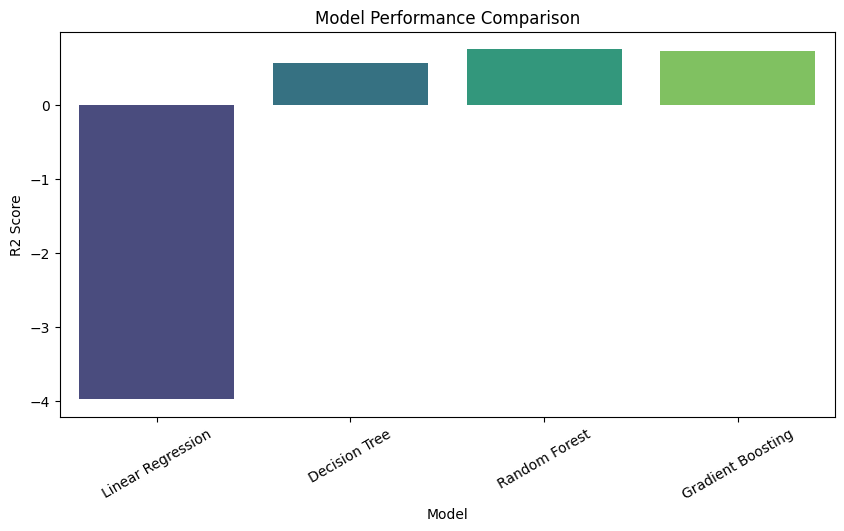

Best Model: Random Forest


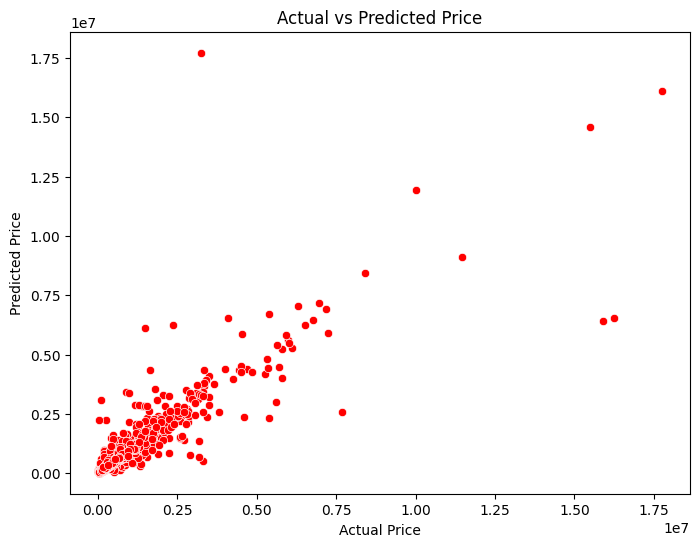

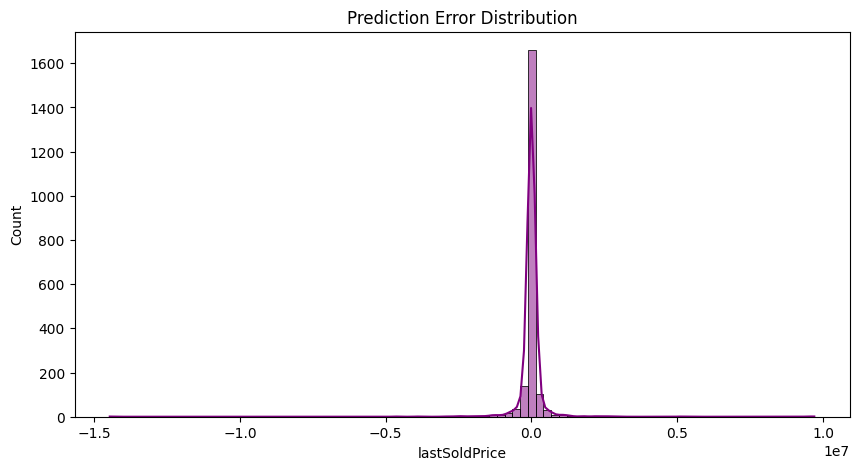


FINAL RESULTS
Linear Regression : -3.9767
Decision Tree : 0.5641
Random Forest : 0.7561
Gradient Boosting : 0.7353
BEST MODEL: Random Forest


In [13]:
# ============================================================
# REAL ESTATE PRICE PREDICTION - COMPLETE ML PIPELINE
# NO DATA LEAKAGE
# ============================================================




from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer


from sklearn.linear_model import LinearRegression


from sklearn.tree import DecisionTreeRegressor


from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)





# ============================================================
# DROP TEXT COLUMN
# ============================================================
# Long description creates noise

if "text" in df.columns:

    df=df.drop(
        "text",
        axis=1
    )



# ============================================================
# REMOVE DATA LEAKAGE COLUMNS
# ============================================================

leakage_cols=[

    "sold_list_ratio",
    "price_per_sqft_sold",
    "sold_vs_asking"

]


for col in leakage_cols:

    if col in df.columns:

        df=df.drop(
            col,
            axis=1
        )



# ============================================================
# FEATURES AND TARGET
# ============================================================

X=df.drop(
    "lastSoldPrice",
    axis=1
)


y=df[
    "lastSoldPrice"
]



print(
    X.shape,
    y.shape
)




# ============================================================
# TRAIN TEST SPLIT
# ============================================================
# BEFORE preprocessing

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)



# ============================================================
# IDENTIFY COLUMNS
# ============================================================

numeric_cols = X.select_dtypes(

    include=np.number

).columns


categorical_cols = X.select_dtypes(

    include="object"

).columns



print(
    "Numerical:",
    len(numeric_cols)
)


print(
    "Categorical:",
    len(categorical_cols)
)




# ============================================================
# NUMERICAL PIPELINE
# ============================================================

numeric_pipeline=Pipeline(

steps=[


(
"imputer",

SimpleImputer(
strategy="median"
)

),


(
"scaler",

StandardScaler()

)


]

)




# ============================================================
# CATEGORICAL PIPELINE
# ============================================================

categorical_pipeline=Pipeline(

steps=[


(
"imputer",

SimpleImputer(
strategy="most_frequent"
)

),



(
"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)


]

)




# ============================================================
# COLUMN TRANSFORMER
# ============================================================

preprocessor=ColumnTransformer(

transformers=[


(
"num",

numeric_pipeline,

numeric_cols

),



(
"cat",

categorical_pipeline,

categorical_cols

)


]

)




# ============================================================
# MODELS
# ============================================================


models={


"Linear Regression":

LinearRegression(),



"Decision Tree":

DecisionTreeRegressor(

random_state=42

),



"Random Forest":

RandomForestRegressor(

n_estimators=300,

random_state=42,

n_jobs=-1

),



"Gradient Boosting":

GradientBoostingRegressor(

random_state=42

)


}



results={}

trained_models={}



# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n====================")
    print(name)
    print("====================")


    pipe=Pipeline(

    steps=[


    (
    "preprocessor",
    preprocessor
    ),


    (
    "model",
    model
    )


    ]

    )


    pipe.fit(

        X_train,

        y_train

    )



    prediction=pipe.predict(

        X_test

    )



    mae=mean_absolute_error(

        y_test,

        prediction

    )



    rmse=np.sqrt(

        mean_squared_error(

            y_test,

            prediction

        )

    )



    r2=r2_score(

        y_test,

        prediction

    )



    results[name]=r2


    trained_models[name]=pipe



    print(
        "MAE:",
        round(mae,2)
    )


    print(
        "RMSE:",
        round(rmse,2)
    )


    print(
        "R2 Score:",
        round(r2,4)
    )





# ============================================================
# MODEL COMPARISON GRAPH
# ============================================================


result_df=pd.DataFrame({

"Model":results.keys(),

"R2 Score":results.values()

})



plt.figure(figsize=(10,5))


sns.barplot(

data=result_df,

x="Model",

y="R2 Score",

palette="viridis"

)


plt.title(

"Model Performance Comparison"

)


plt.xticks(rotation=30)


plt.show()






# ============================================================
# BEST MODEL
# ============================================================

best_name=max(

results,

key=results.get

)


print(

"Best Model:",

best_name

)



best_model=trained_models[

best_name

]





# ============================================================
# ACTUAL VS PREDICTED GRAPH
# ============================================================

pred=best_model.predict(

X_test

)



plt.figure(figsize=(8,6))


sns.scatterplot(

x=y_test,

y=pred,

color="red"

)


plt.xlabel(

"Actual Price"

)


plt.ylabel(

"Predicted Price"

)


plt.title(

"Actual vs Predicted Price"

)


plt.show()






# ============================================================
# RESIDUAL ANALYSIS
# ============================================================

residual = y_test - pred



plt.figure(figsize=(10,5))


sns.histplot(

residual,

kde=True,

color="purple"

)


plt.title(

"Prediction Error Distribution"

)


plt.show()







# ============================================================
# FINAL RESULT
# ============================================================

print("\n============================")

print("FINAL RESULTS")

print("============================")


for model,score in results.items():

    print(

    model,

    ":",

    round(score,4)

    )



print("============================")


print(

"BEST MODEL:",

best_name

)

## Thanks.................Please Upvotes